# Used Car Price Prediction Data Understanding 

Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Load Dataset

In [5]:
df = pd.read_csv("../data/raw/cardekho_dataset.csv")

df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


Check dimensions

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 15411
Columns: 14


Understand the columns

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 1.6 MB


Statistical summary

In [8]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


Check Missing Values

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
Unnamed: 0,0,0.0
car_name,0,0.0
brand,0,0.0
model,0,0.0
vehicle_age,0,0.0
km_driven,0,0.0
seller_type,0,0.0
fuel_type,0,0.0
transmission_type,0,0.0
mileage,0,0.0


#### Check Duplicate Rows

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#### Check unique values

In [11]:
categorical_columns = [
    "brand",
    "model",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

for column in categorical_columns:
    print(f"\n{column}")
    print("Unique values:", df[column].nunique())
    print(df[column].unique()[:20])


brand
Unique values: 32
<StringArray>
[       'Maruti',       'Hyundai',          'Ford',       'Renault',
          'Mini', 'Mercedes-Benz',        'Toyota',    'Volkswagen',
         'Honda',      'Mahindra',        'Datsun',          'Tata',
           'Kia',           'BMW',          'Audi',    'Land Rover',
        'Jaguar',            'MG',         'Isuzu',       'Porsche']
Length: 20, dtype: str

model
Unique values: 120
<StringArray>
[       'Alto',       'Grand',         'i20',    'Ecosport',     'Wagon R',
         'i10',       'Venue',       'Swift',       'Verna',      'Duster',
      'Cooper',        'Ciaz',     'C-Class',      'Innova',      'Baleno',
 'Swift Dzire',       'Vento',       'Creta',        'City',      'Bolero']
Length: 20, dtype: str

seller_type
Unique values: 3
<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

fuel_type
Unique values: 5
<StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str

tra

#### Check target variable

In [12]:
print(df["selling_price"].describe())
print("==================================")
print("Minimum price:", df["selling_price"].min())
print("Maximum price:", df["selling_price"].max())
print("Average price:", df["selling_price"].mean())
print("Median price:", df["selling_price"].median())

count    1.541100e+04
mean     7.749711e+05
std      8.941284e+05
min      4.000000e+04
25%      3.850000e+05
50%      5.560000e+05
75%      8.250000e+05
max      3.950000e+07
Name: selling_price, dtype: float64
Minimum price: 40000
Maximum price: 39500000
Average price: 774971.1164103562
Median price: 556000.0


#### Look at the price distribution

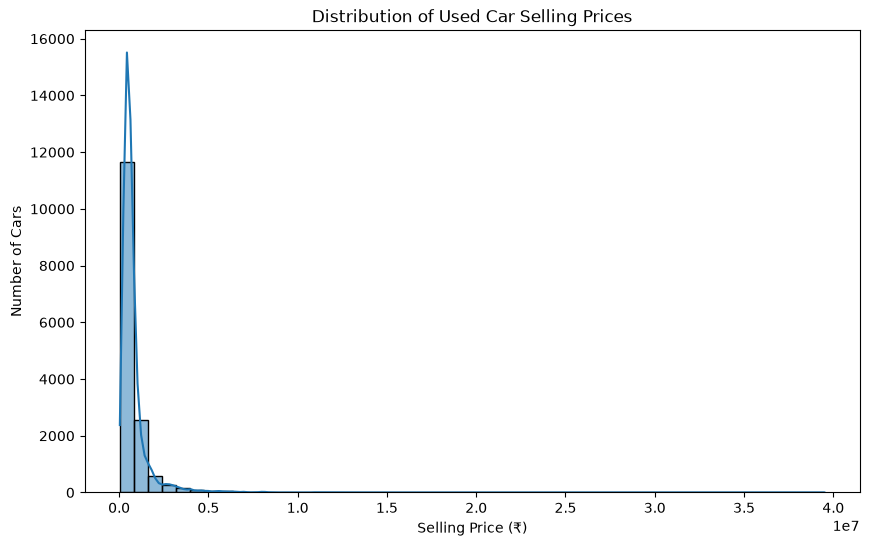

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["selling_price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Used Car Selling Prices")
plt.xlabel("Selling Price (₹)")
plt.ylabel("Number of Cars")

plt.show()

#### Check numerical correlations

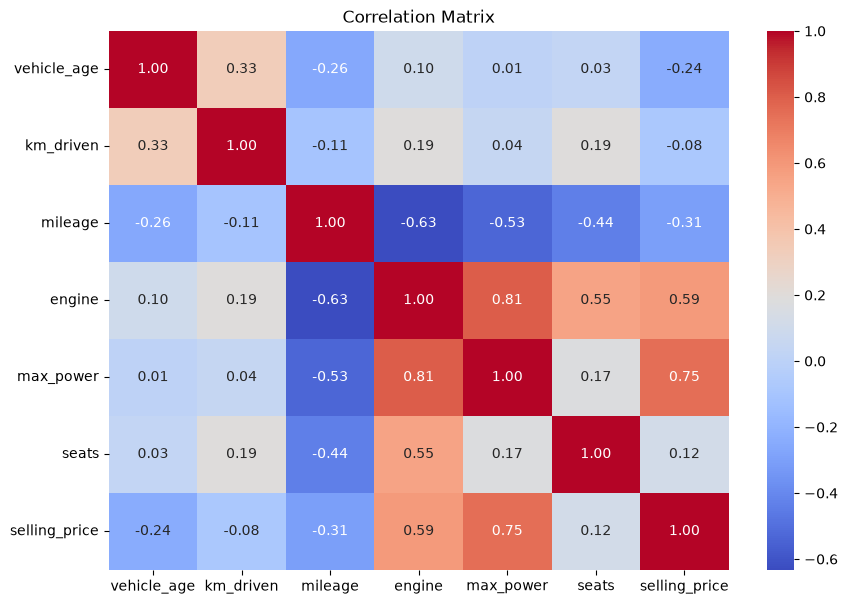

In [15]:
numerical_columns = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    # "fuel_type",
    # "transmission_type",
    # "seller_type",
    "selling_price"
]

correlation = df[numerical_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

#### Check price against car age

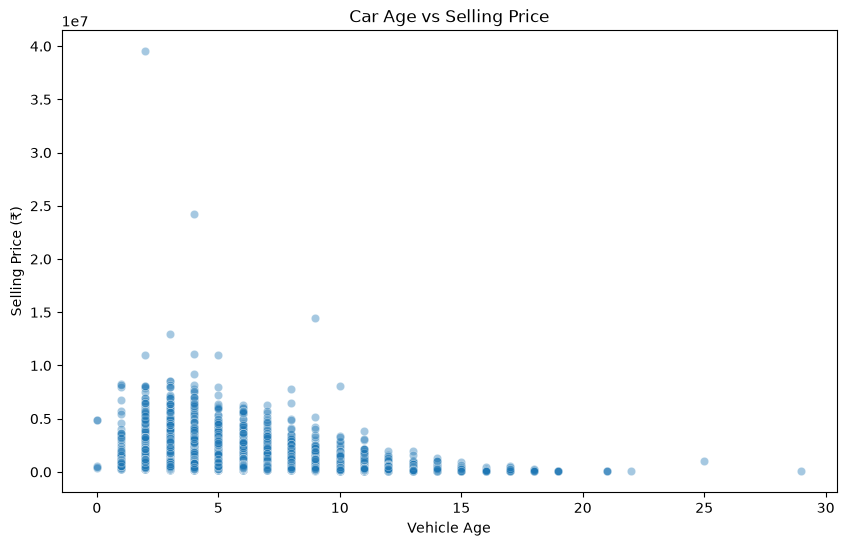

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="vehicle_age",
    y="selling_price",
    alpha=0.4
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price (₹)")

plt.show()

#### Check kilometers vs price

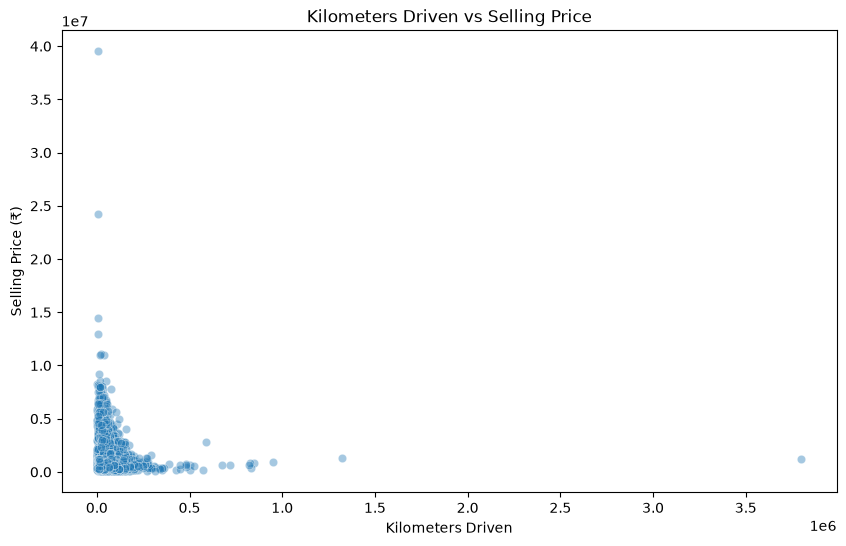

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price",
    alpha=0.4
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (₹)")

plt.show()

#### Brand analysis

In [19]:
brand_stats = (
    df.groupby("brand")["selling_price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

brand_stats

,count,mean,median
brand,,,
Ferrari,1,3.950000e+07,39500000.0
Rolls-Royce,1,2.420000e+07,24200000.0
Bentley,3,9.266667e+06,8100000.0
Maserati,2,6.100000e+06,6100000.0
Mercedes-AMG,1,5.100000e+06,5100000.0
Porsche,21,5.161190e+06,5000000.0
Lexus,10,5.146500e+06,4600000.0
Volvo,20,3.729700e+06,3750000.0
Land Rover,51,3.823902e+06,3400000.0


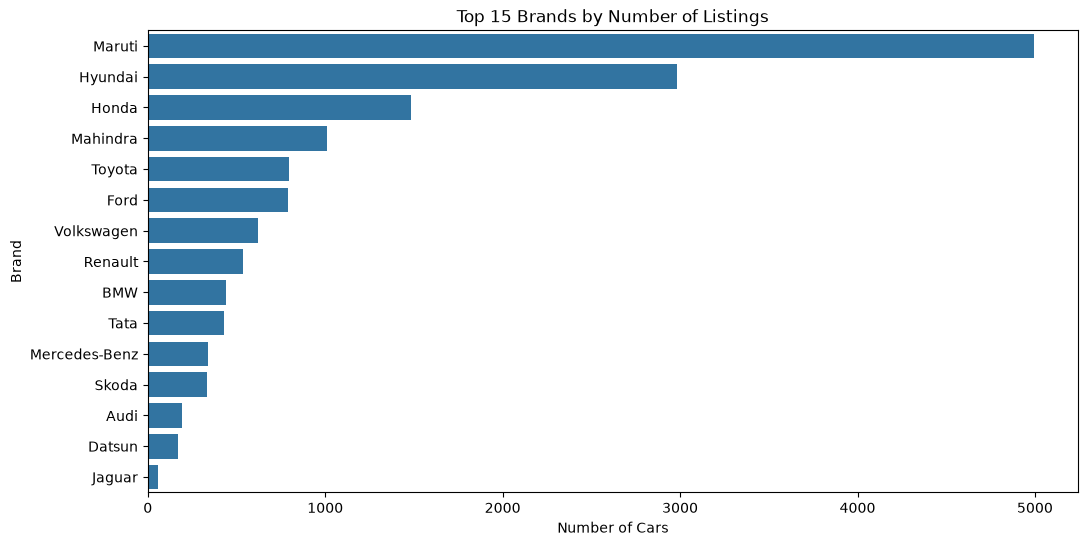

In [20]:
top_brands = df["brand"].value_counts().head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.title("Top 15 Brands by Number of Listings")
plt.xlabel("Number of Cars")
plt.ylabel("Brand")

plt.show()

#### Fuel type analysis

In [21]:
fuel_stats = (
    df.groupby("fuel_type")["selling_price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

fuel_stats

,count,mean,median
fuel_type,,,
Electric,4,1.853500e+06,1857500.0
Diesel,7419,1.000469e+06,700000.0
Petrol,7643,5.728619e+05,460000.0
CNG,301,4.176877e+05,370000.0
LPG,44,2.062727e+05,182500.0


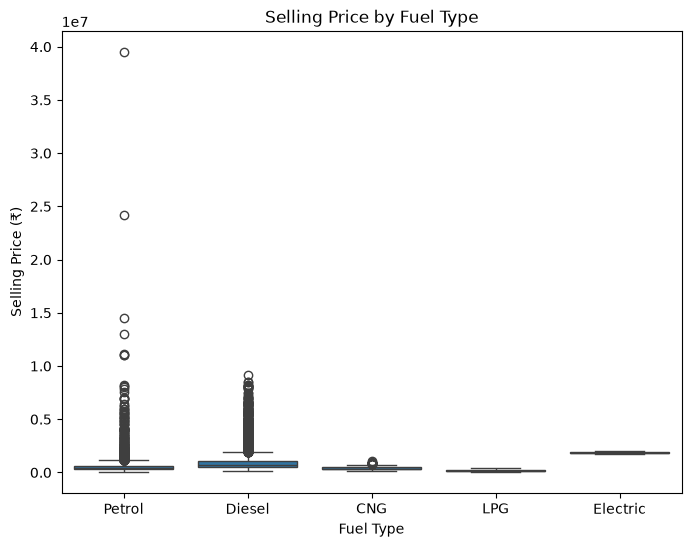

In [24]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="fuel_type",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (₹)")

plt.show()

#### Transmission analysis

In [25]:
transmission_stats = (
    df.groupby("transmission_type")["selling_price"]
    .agg(["count", "mean", "median"])
)

transmission_stats

,count,mean,median
transmission_type,,,
Automatic,3186,1.579557e+06,1057000.0
Manual,12225,5.652852e+05,500000.0


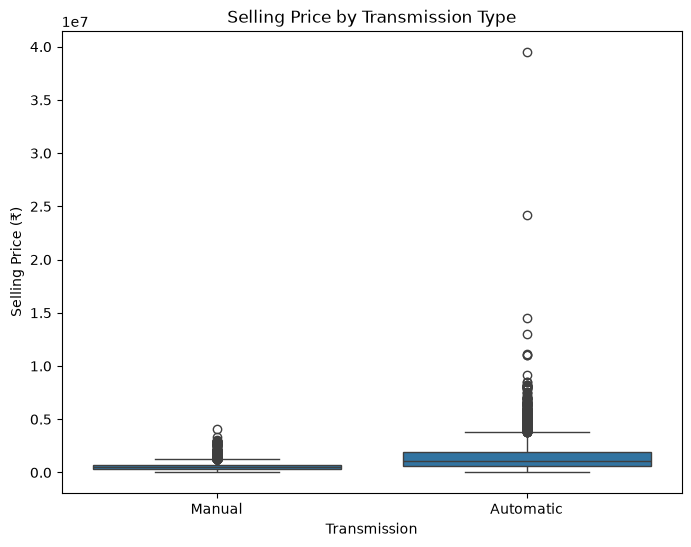

In [26]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="transmission_type",
    y="selling_price"
)

plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price (₹)")

plt.show()

#### Inspect suspicious numerical values

In [27]:
for column in numerical_columns:
    print(f"\n========== {column} ==========")
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())


========== vehicle_age ==========
Minimum: 0
Maximum: 29
Mean: 6.0363376808772955
Median: 6.0

========== km_driven ==========
Minimum: 100
Maximum: 3800000
Mean: 55616.48063071832
Median: 50000.0

========== mileage ==========
Minimum: 4.0
Maximum: 33.54
Mean: 19.701151125819223
Median: 19.67

========== engine ==========
Minimum: 793
Maximum: 6592
Mean: 1486.0577509571085
Median: 1248.0

========== max_power ==========
Minimum: 38.4
Maximum: 626.0
Mean: 100.5882538446564
Median: 88.5

========== seats ==========
Minimum: 0
Maximum: 9
Mean: 5.325481798715203
Median: 5.0

========== selling_price ==========
Minimum: 40000
Maximum: 39500000
Mean: 774971.1164103562
Median: 556000.0


#### Remove the useless index

In [28]:
df = df.drop(columns=["Unnamed: 0"])

df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


#### Save the cleaned basic dataset

In [30]:
df.to_csv(
    "../data/processed/cardekho_cleaned.csv",
    index=False
)

print("Saved successfully!")
print(df.shape)

Saved successfully!
(15411, 13)
